In [6]:
import dill as pk
import numpy as np

In [3]:
with open("/home/charles/Downloads/par_results_final_fit.dill", "rb") as f:
   par_dict = pk.load(f)

In [4]:
par_dict

{'par_names': array(['x0', 'y0', 'z0', 'r', 'theta', 'beta', 'amp', 'dx_1', 'dy_1',
        'dz_1', 'P0', 'r_s', 'gamma', 'alpha', 'beta', 'z', 'dx_g', 'dy_g',
        'sigma', 'amp_g'], dtype='<U5'),
 'parameters': array([-3.34232640e+01,  7.26858000e+00,  0.00000000e+00,  2.92480936e+01,
         0.00000000e+00,  1.28464393e+00,  7.19444463e-02,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.49227092e+00,  4.40270133e+00,
        -1.03584251e+00,  1.39257955e+00,  2.21483160e+00,  1.19000000e+00,
         1.39715106e+00, -3.37115726e+00,  5.19470104e+00,  1.55951974e-03]),
 'errs': array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.55903130e-01,
        0.00000000e+00, 2.02733430e-02, 1.34049406e-03, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 2.32156075e-02, 4.03345540e-02,
        8.61248423e-02, 2.15411099e-02, 1.01428306e-02, 0.00000000e+00,
        7.35326310e-02, 7.46485559e-02, 4.74486328e-02, 1.88444027e-05]),
 'cov': array([[ 0.00000000e+00, 

In [28]:
#L = np.linalg.cholesky(par_dict["cov"])           # Lower Cholesky decomposition.
expected_values = par_dict["parameters"]   # mean if PURELY Gaussian.

In [22]:
rowsum = np.sum(par_dict["cov"], axis=0)
print(rowsum.shape)
nonzero = np.where(rowsum != 0)

(20,)


In [12]:
nonzero

(array([ 3,  5,  6, 10, 11, 12, 13, 14, 16, 17, 18, 19]),)

In [18]:
cov_intermediate = par_dict["cov"][nonzero]

In [20]:
mycov = cov_intermediate[:,nonzero[0]]
mycov.shape
#par_dict["cov"].shape

(12, 12)

In [53]:
#print()
mydiag = np.diag(mycov)
#print()   # If you had uncertainties (without covariance), it should be these.
#print()
for pn, expected, unc in zip(par_dict['par_names'][nonzero], expected_values[nonzero], np.sqrt(mydiag)):
    print(pn, expected, unc)

r 29.24809355437161 0.355903129540248
beta 1.2846439347504761 0.020273342957507712
amp 0.07194444632845963 0.0013404940590019498
P0 1.4922709177301448 0.02321560746943293
r_s 4.402701333920457 0.040334554038775935
gamma -1.0358425119298689 0.08612484233947214
alpha 1.3925795462824269 0.02154110990624929
beta 2.2148315973186303 0.010142830568292247
dx_g 1.3971510607255377 0.07353263095566798
dy_g -3.3711572600222013 0.07464855593837001
sigma 5.194701040077229 0.04744863280020524
amp_g 0.0015595197403338195 1.884440268102784e-05


In [21]:
print(mycov)

[[ 1.26667038e-01  2.65904449e-03 -1.61417930e-04 -3.39451561e-04
  -8.28435918e-04  1.89898978e-04 -4.97658247e-05  2.71646252e-04
  -3.77652868e-04 -7.81276977e-05 -3.95355712e-04 -1.27437491e-07]
 [ 2.65904449e-03  4.11008435e-04  6.62190755e-06  2.39013700e-05
   6.13551413e-05 -2.76344983e-05 -1.80437302e-06 -2.34136469e-05
   6.12363323e-06  8.21341559e-06  2.47622251e-05  6.72905878e-09]
 [-1.61417930e-04  6.62190755e-06  1.79692432e-06 -6.33013469e-07
  -1.73568444e-06  1.44769018e-06  5.29624637e-08  5.16001158e-07
  -1.17615738e-06  2.07876223e-07 -2.37422588e-06 -5.20072409e-10]
 [-3.39451561e-04  2.39013700e-05 -6.33013469e-07  5.38964430e-04
  -2.06730033e-04 -2.76156887e-04 -8.75739619e-05  5.20869785e-05
  -1.11258735e-05  3.29467667e-05  1.17836255e-04  2.88328684e-08]
 [-8.28435918e-04  6.13551413e-05 -1.73568444e-06 -2.06730033e-04
   1.62687625e-03 -3.22164522e-04 -1.35415554e-04  1.11636611e-04
   5.04480176e-05 -8.59501152e-05  1.29966887e-04 -3.54477297e-09]
 [ 1.

In [23]:
L = np.linalg.cholesky(mycov)

In [25]:
rng = np.random.default_rng()
nsamples = 1000
ngoodpar = mycov.shape[0]
rand_gen = rng.normal(size=(nsamples, ngoodpar))  # Unscaled random values. (Or just scaled to unity)

In [30]:
rotated = np.dot(L,rand_gen.T)  # Both scales the random values and rotates according to covariance (correlation). 
# "Rotating about zero".
generated = rotated.T + expected_values[nonzero]   # Add means back in, full distribution.

In [31]:
generated.shape

(1000, 12)

In [34]:
#from profile_models import gNFW, iso_beta
def gNFW(r, p_0, r_s, alpha, beta, gamma):
    expression = ((r / r_s) ** -gamma) * (1 + (r / r_s) ** alpha) ** ((gamma - beta) / alpha)
    return p_0 * expression

def iso_beta(r, p_0, r_c, beta):
    expression = (1 + (r / r_c) ** 2) ** (-1.5 * beta)
    return p_0 * expression

In [37]:
print(par_dict['par_names'][nonzero])

['r' 'beta' 'amp' 'P0' 'r_s' 'gamma' 'alpha' 'beta' 'dx_g' 'dy_g' 'sigma'
 'amp_g']


In [38]:
R_SZ = np.arange(0.1, 100.0, 0.1)   # arcseconds

In [43]:
p_profiles_main = []
p_profiles_sub = []

for sample in generated:
    #print(sample.shape)
    pressure_main = gNFW(R_SZ, sample[3], sample[4], sample[6], sample[7], sample[5])  # alpha, beta, gamma in gNFW call.
    pressure_sub = iso_beta(R_SZ, sample[2], sample[0], sample[1])
    
    p_profiles_main.append(pressure_main)
    p_profiles_sub.append(pressure_sub)

    #import pdb;pdb.set_trace()

p_p5_main, p_p50_main, p_p95_main = np.percentile(p_profiles_main, [5, 50, 95], axis=0)
p_p5_sub, p_p50_sub, p_p95_sub = np.percentile(p_profiles_sub, [5, 50, 95], axis=0)

results_dict = {
    "P_p5_main": p_p5_main,
	"P_p50_main": p_p50_main,
	"P_p95_main": p_p95_main,
	"P_p5_sub": p_p5_sub,
	"P_p50_sub": p_p50_sub,
	"P_p95_sub": p_p95_sub,
}


(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,)
(12,

In [45]:
import matplotlib.pyplot as plt

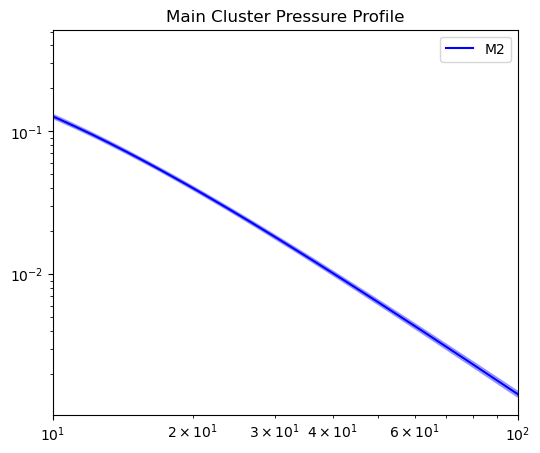

In [50]:
fig, (ax1) = plt.subplots(1, 1, figsize=(6, 5), sharey=True, gridspec_kw={"wspace": 0.0})

z = 1.189
#kpc_per_arcsec = Planck18.kpc_proper_per_arcmin(z).to(u.kpc / u.arcsec).value

ax1.set_title("Main Cluster Pressure Profile")
#ax1.loglog(R_SZ, main_cluster_sz_profile, c="blue", label="M2")
ax1.loglog(R_SZ, results_dict["P_p50_main"], c="blue", label="M2")
ax1.fill_between(R_SZ, results_dict["P_p5_main"], results_dict["P_p95_main"], color="blue", alpha=0.3)
ax1.set_xlim([10.0,1e2])
ax1.legend()